In [159]:
import numpy as np
from matplotlib import pyplot as plt

Варіант - 3

Мета роботи:

• Створити багатошарову нейронну мережу прямого розповсюдження сигналу за допомогою бiблiотеки Numpy Python.

• Реалiзувати власний клас, який наслiдує клас object.

• Реалiзувати алгоритм зворотного розповсюдження помилки (back propagation). Налаштувати ваги нейронної мережi.

• Використати багатошарову нейронну мережу прямого розповсюдження
для класифiкацiї зображень типу MNIST.

Хiд виконання роботи
1. Завантажити простий набiр зображень згiдно з варiантом. (Kuzushiji MNIST)
2. Виконати пiдготовку даних для навчання - за необхiдностi, залежно вiд
вхiдного набору. Наприклад, нормалiзувати данi тощо.
3. За необхiдностi розбити данi на навчальну i перевiрочну множини у спiввiдношеннi 80%: 20%. Звернути увагу, що завантаженi данi вже можуть бути розбитi на навчальну i перевiрочну множини.
4. Побудувати базову мережу прямого розповсюдження сигналу з єдиним
скритим шаром i output шаром softmax. Для створення моделi реалiзувати власний клас, який наслiдує клас object. Ваги iнiцiалiзувати невеликими випадковими значеннями, якi нормально розподiленi з нульовим

середнiм та малою дисперсiєю.

5. Реалiзувати алгоритм зворотного розповсюдження помилки (back propagation).

6. Функцiєю втрат задати перехресну ентропiю.

7. Налаштувати ваги побудованої мережi реалiзованим алгоритмом back
propagation.
8. Побудувати кiлька альтернативних мереж MLP з кiлькома скритими
шарами ReLU або tanh. Налаштувати їх ваги реалiзованим алгоритмом
back propagation.
9. Для кожної моделi побудувати:

• графiки змiни значень функцiї втрат на тренувальнiй i перевiрочнiй множинах по мiрi навчання моделi, тобто залежно вiд кiлькостi епох,
• графiки змiни показника accuracy на тренувальнiй i перевiрочнiй
множинах по мiрi навчання моделi.
10. Пiдiбрати значення гiперпараметра швидкостi навчання.
11. Обрати для нейронiв скритих шарiв рiзнi функцiї активацiї: LeakyReLU,
Parametric LeakyReLU, ELU. Спробувати з’ясувати чи впливає вибiр
функцiї активацiї на:
• час навчання мережi,
• якiсть роботи мережi (фiнальне значення accuracy) на перевiрочнiй
множинi,
• час надання прогнозу мережею.
12. Вiдобразити кiлька зображень, невiрно класифiкованих моделлю.

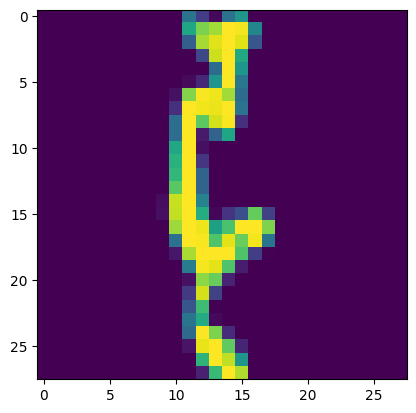

In [160]:
plt.imshow(np.load('/kaggle/input/datasets/anokas/kuzushiji/kmnist-test-imgs.npz')['arr_0'][0])

In [161]:
#80/20 train eval split +
#normal init +
#ReLU / tanh +
#softmax activation head +
#CE loss +
#leakyelu +
#loss and acuracy logging +
#train time logging for different models +

#show missclassification +

In [162]:
def unbroadcast(grad, target_shape):
    if grad.shape == target_shape:
        return grad

    ndim_diff = grad.ndim - len(target_shape)
    if ndim_diff > 0:
        grad = grad.sum(axis=tuple(range(ndim_diff)))

    for i, dim in enumerate(target_shape):
        if dim == 1 and grad.shape[i] > 1:
            grad = grad.sum(axis=i, keepdims=True)
            
    return grad
    
class Values:
    def __init__(self, data, child=(), grad = None):
        #assert len(data.shape) == 2 #?
        self.data = data
        self._backward = lambda: None
        if grad is None:
            self.grad = np.zeros_like(self.data, dtype = float)
        else:
            self.grad = grad
        self.child = set(child)


    def __add__(self, x):
        if not isinstance(x, Values):
            x = Values(x)
        out = Values(self.data + x.data, (self, x))
        def _back():
            self.grad += unbroadcast(out.grad, self.data.shape)
            x.grad += unbroadcast(out.grad, x.data.shape)
            
        out._backward = _back
        return out

    def __neg__(self):
        minus = -1 * np.ones_like(self.data)
        return self*minus

    def __sub__(self, x):
        return self + (-x)

    def __mul__(self, x):
        if isinstance(x, Values) == False:
            x = Values(x)
        assert x.data.shape == self.data.shape
        out = Values(self.data * x.data, (self, x))
        
        def _back():            
            self.grad += unbroadcast(out.grad * x.data, self.data.shape)
            x.grad += unbroadcast(out.grad * self.data, x.data.shape)
            
        out._backward = _back
        return out

    def __truediv__(self, x):
        if isinstance(x, Values) == False:
            x = Values(x)
        assert x.data.shape == self.data.shape
        out = Values(self.data / x.data, (self, x))
        def _back():
            self.grad += unbroadcast(out.grad / x.data, self.data.shape)
            x.grad += unbroadcast(out.grad * (-self.data / (x.data ** 2)), x.data.shape)
            
        out._backward = _back
        return out
    
    def __matmul__(self, x):
        # self.data @ x.data 
        if isinstance(x, Values) == False:
            x = Values(x)

        out = Values(self.data @ x.data, (self, x))
        
        def _back():
            temp_out_grad = out.grad
            if temp_out_grad.ndim == 1:
                temp_out_grad = temp_out_grad.reshape(-1, 1)

            temp_x_data = x.data 
            if temp_x_data.ndim == 1:
                temp_x_data = temp_x_data.reshape(1, -1)
            else:
                temp_x_data = temp_x_data.T
            
            self.grad += temp_out_grad @ temp_x_data

            x.grad += np.array(self.data.T @ out.grad).reshape(x.grad.shape)

        out._backward = _back
        return out
    
    def abs(self):
        out = Values(np.absolute(self.data), (self,))
        def _back():
            self.grad += np.sign(out.data) * out.grad
        
        out._backward = _back
        return out

    def relu(self):
        zero_mask = np.where(self.data > 0)
        zeros = np.zeros_like(self.data)
        
        zeros[zero_mask] = self.data[zero_mask].copy()
        out = Values(zeros, (self,))
        def _back():
            zeros_grad = np.zeros_like(self.data)
            zeros_grad[zero_mask] = np.ones_like(self.data)[zero_mask]
            self.grad += zeros_grad * out.grad
        
        out._backward = _back
        return out

    def leakyrelu(self, a:float = 0.01):
        zero_mask = np.where(self.data > 0)
        zeros = np.full_like(self.data, a)
        
        zeros[zero_mask] = self.data[zero_mask].copy()
        out = Values(zeros, (self,))
        def _back():
            zeros_grad = np.full_like(self.data, a)
            zeros_grad[zero_mask] = np.ones_like(self.data)[zero_mask]
            self.grad += zeros_grad * out.grad
        
        out._backward = _back
        return out

    def exp(self):
        ex = np.exp(self.data)
        out = Values(ex, (self,))
        def _back():
            self.grad += out.data* out.grad
        
        out._backward = _back
        return out

    def tanh(self):
        tan = np.tanh(self.data)
        out = Values(tan, (self,))
        def _back():
            self.grad += (1-tan**2) * out.grad
        
        out._backward = _back
        return out

    # def log(self):
    #     out = Values(np.log(self.data), (self,))
    #     def _back():
    #         self.grad += out.grad/self.data

    #     out._backward = _back
    #     return out
            
    def log_softmax(self, axis=-1):
        x_max = np.max(self.data, axis = axis, keepdims = True)
        centered = self.data - x_max
        exps = np.exp(centered)
        sums = np.sum(exps, axis = axis, keepdims = True)
        out_data = centered - np.log(sums)
        
        out = Values(out_data, (self,))
        def _back():
            S = np.exp(out.data)
            sum_dout = np.sum(out.grad, axis = axis, keepdims = True)
            self.grad += out.grad - (S*sum_dout)
            
        out._backward = _back
        return out
        
    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.child:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = np.ones_like(self.data)
        for v in reversed(topo):
            v._backward()
            
def cross_entropy(log_probs, targets):
    
    bs = targets.shape[0]
    loss_data = -np.sum(log_probs.data * targets)/bs
    out = Values(np.array(loss_data), (log_probs,))
    
    def _back():
        log_probs.grad += (-targets) * out.grad/bs
        
    out._backward = _back
    return out

In [163]:
class Linear:
    def __init__(self, in_dim, out_dim):
        try:
            self.w = np.random.normal(loc=0.0, scale=0.01, size= in_dim*out_dim).reshape(out_dim, in_dim)
            self.b = np.random.normal(loc=0.0, scale=0.01, size=out_dim).reshape(out_dim, 1)
        except:
            print("revise your in, out dims choice in Linear layer init")

        self.weight = Values(self.w)
        self.bias = Values(self.b)
        self.params = [self.weight, self.bias]

    def __call__(self, x):
        x = self.weight @ x + self.bias
        return x

class ReLU:
    def __init__(self,):
        self.params = []
    def __call__(self, x):
        assert isinstance(x, Values)
        x = x.relu()
        return x

class LeakyReLU:
    def __init__(self, a:float = 0.3):
        self.a = a
        self.params = []
    def __call__(self, x):
        assert isinstance(x, Values)
        x = x.leakyrelu(self.a)
        return x

class Tanh:
    def __init__(self,):
        self.params = []
    def __call__(self, x):
        assert isinstance(x, Values)
        x = x.tanh()
        return x

class LogSoftMax:
    def __init__(self):
        self.params = []
    def __call__(self, x):
        assert isinstance(x, Values)
        x = x.log_softmax(0)
        return x

In [164]:
class SGD:
    def __init__(self, layers, lr):
        self.lr = lr
        self.paramters = []
        self.layers = layers
        self._find_parametrs()

    def _find_parametrs(self):
        for layer in self.layers:
            for parameter in layer.params:
                self.paramters.append(parameter)
                
    def optimize(self, loss):
        for parameter in self.paramters:
            parameter.data -= self.lr * loss * parameter.grad

    def zero_grad(self):
        for parameter in self.paramters:
            parameter.data -= 0

In [165]:
class ResMLP:
    def __init__(self):
        self.l1 = Linear(28*28, 64)
        self.act1 = ReLU()
        self.l2 = Linear(64, 64)
        self.act2 = ReLU()
        self.l3 = Linear(64, 64)
        self.act3 = ReLU()
        self.l4 = Linear(64, 10)
        self.head = LogSoftMax()
        self.layers = [
            self.l1, self.act1, 
            self.l2, self.act2, 
            #self.l3, self.act3, 
            self.l4, self.head
        ]

    def __call__(self, x):
        out = x.copy()
        out = self.act1(self.l1(out))
        out = self.act2(self.l2(out)) + out
        #out = self.act3(self.l3(out)) #+ out
        out = self.head(self.l4(out))
        return out
        
class TahnResMLP:
    def __init__(self):
        self.l1 = Linear(28*28, 64)
        self.act1 = Tanh()
        self.l2 = Linear(64, 64)
        self.act2 = Tanh()
        self.l4 = Linear(64, 10)
        self.head = LogSoftMax()
        self.layers = [
            self.l1, self.act1, 
            self.l2, self.act2, 
            self.l4, self.head
        ]

    def __call__(self, x):
        out = x.copy()
        out = self.act1(self.l1(out))
        out = self.act2(self.l2(out)) + out
        out = self.head(self.l4(out))
        return out

class LeakyResMLP:
    def __init__(self):
        self.l1 = Linear(28*28, 64)
        self.act1 = LeakyReLU(0.03)
        self.l2 = Linear(64, 64)
        self.act2 = LeakyReLU(0.1)
        self.l4 = Linear(64, 10)
        self.head = LogSoftMax()
        self.layers = [
            self.l1, self.act1, 
            self.l2, self.act2, 
            self.l4, self.head
        ]

    def __call__(self, x):
        out = x.copy()
        out = self.act1(self.l1(out))
        out = self.act2(self.l2(out)) + out
        out = self.head(self.l4(out))
        return out

In [166]:
import time
from tqdm import tqdm
from sklearn.metrics import accuracy_score

In [167]:
#dataset prep
#train
train_size = 512
x_a = np.load('/kaggle/input/datasets/anokas/kuzushiji/kmnist-train-imgs.npz')['arr_0'][:train_size, :, :]
y_a = np.load('/kaggle/input/datasets/anokas/kuzushiji/kmnist-train-labels.npz')['arr_0'][:train_size]
train_set = x_a.transpose(1, 2, 0) / 255.
train_set = train_set.reshape(28*28, -1)
train_size = train_set.shape[-1]
train_gt_set = np.zeros((10, train_size))
train_gt_set[y_a, np.arange(train_size)] = 1

#test
test_size = 128
x_b = np.load('/kaggle/input/datasets/anokas/kuzushiji/kmnist-test-imgs.npz')['arr_0'][:test_size, :, :]
y_b = np.load('/kaggle/input/datasets/anokas/kuzushiji/kmnist-test-labels.npz')['arr_0'][:test_size]
test_set = x_b.transpose(1, 2, 0) / 255.
test_set = test_set.reshape(28*28, -1)
test_size = test_set.shape[-1]
test_gt_set = np.zeros((10, test_size))
test_gt_set[y_b, np.arange(test_size)] = 1

ReLU

100%|██████████| 30/30 [00:01<00:00, 27.64it/s]


t:  1.0891387462615967
CELoos on the last epoch
train:  0.018685567468168972
test:  0.1943048686470062
Accuracy on the last epoch
train:  0.947265625
test:  0.578125


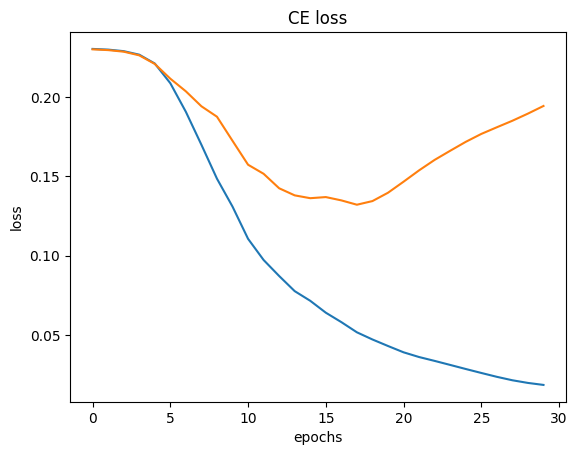

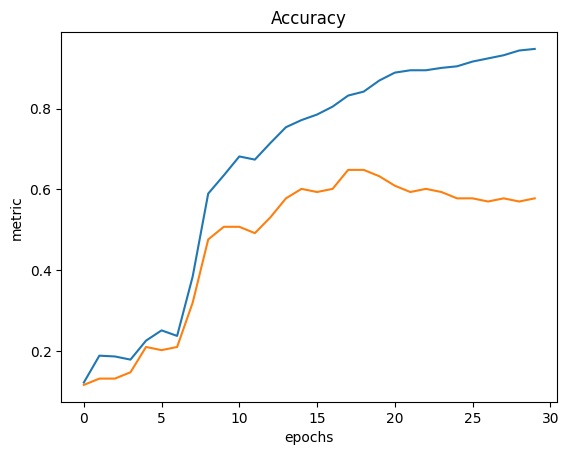

In [168]:
model = ResMLP()
optimizer = SGD(model.layers, lr = 1e-4)

#train params
train_start = time.time()
bs = 32
epochs = 3_0
eval_freq = 1

#train
train_start = time.time()
n_s = train_size // bs

train_losses = []
train_acuracy_scores = []
test_losses = []
test_acuracy_scores = []
train_apendix = train_size % bs
test_apendix = test_size % bs
for step in tqdm(range(epochs)):
    preds = []
    cum_loss = 0
    for i in range(n_s):
        #batch prep
        input = train_set[:, i*bs:(i+1)*bs]
        target = train_gt_set[:, i*bs:(i+1)*bs]        
        #batch processing
        optimizer.zero_grad()
        # for layer in model:
        #     out = layer(out)
        out = model(input.copy())
            
        #loss calc
        loss = cross_entropy(out, target)
        loss.backward()
        optimizer.optimize(loss.data)
        
        #loggin
        predicted = np.argmax(out.data, axis = 0)
        preds.append(predicted)
        cum_loss += loss.data

    #eval
    if step % eval_freq == 0:
        #train_eval
        ac = accuracy_score(np.stack(preds).reshape(-1,), y_a[:train_size - train_apendix])
        train_acuracy_scores.append(ac)
        train_losses.append(cum_loss/(train_size - train_apendix))

        #test_eval
        optimizer.zero_grad()
        #out = test_set.copy()
        out = model(test_set.copy())
            
        test_predicted = np.argmax(out.data, axis = 0)
        
        test_loss = cross_entropy(out, test_gt_set).data / (test_size)# - eval_apendix)
        test_losses.append(test_loss)
        ac = accuracy_score(np.stack(test_predicted).reshape(-1,), y_b[:test_size])
        test_acuracy_scores.append(ac)
        

train_end = time.time()
print("t: ", train_end - train_start)
print('CELoos on the last epoch')
print('train: ',train_losses[-1])
print('test: ',test_losses[-1])
print('Accuracy on the last epoch')
print('train: ',train_acuracy_scores[-1])
print('test: ',test_acuracy_scores[-1])
plt.plot(train_losses, label = 'train')
plt.plot(test_losses, label = 'test')
plt.title('CE loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()
plt.plot(train_acuracy_scores, label = 'train')
plt.plot(test_acuracy_scores, label = 'test')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('metric')
plt.show()

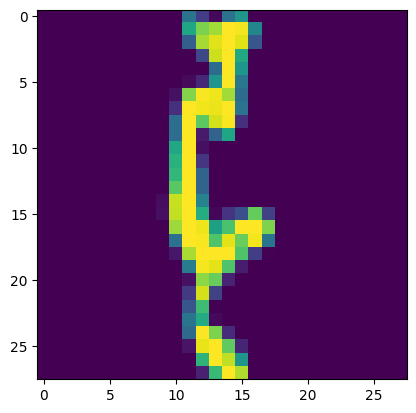

true label:  2
predicted:  [5]


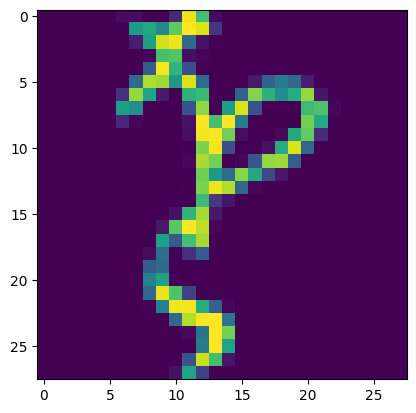

true label:  9
predicted:  [2]


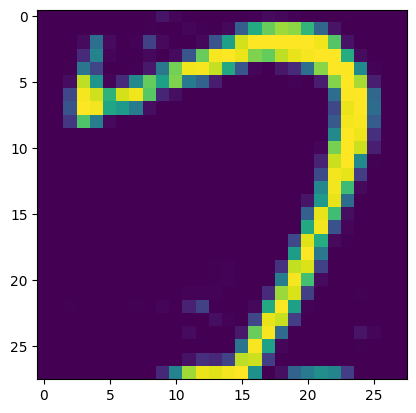

true label:  3
predicted:  [2]
mean time to predict:  0.000881195068359375


In [169]:
stop_flag = 0
mean_time = []
for i in range(100):
    input = test_set[:, i:i+1]
    t_0 = time.time()
    predict = model(input.copy())
    t_1 = time.time()
    mean_time.append(t_1 - t_0)
    pre_label = np.argmax(predict.data, axis = 0)
    if pre_label != y_b[i]:
        plt.imshow(input.reshape(28, -1))
        plt.show()
        print('true label: ', y_b[i])
        print('predicted: ', pre_label)
        stop_flag +=1

    if stop_flag ==3:
        break
print('mean time to predict: ', np.mean(np.array(mean_time)))

Tanh

100%|██████████| 30/30 [00:01<00:00, 27.33it/s]


t:  1.101297378540039
CELoos on the last epoch
train:  0.016176175464301744
test:  0.1995558088728862
Accuracy on the last epoch
train:  0.95703125
test:  0.6015625


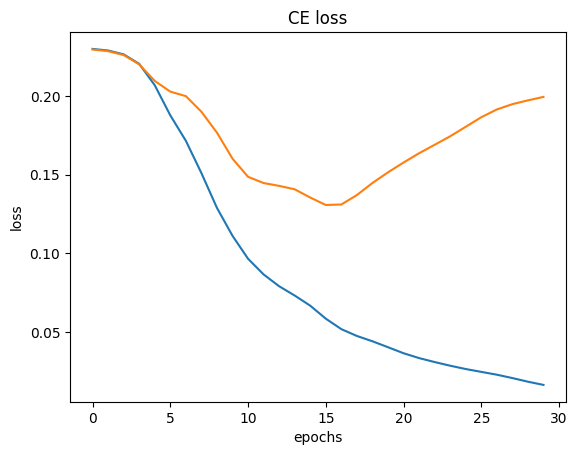

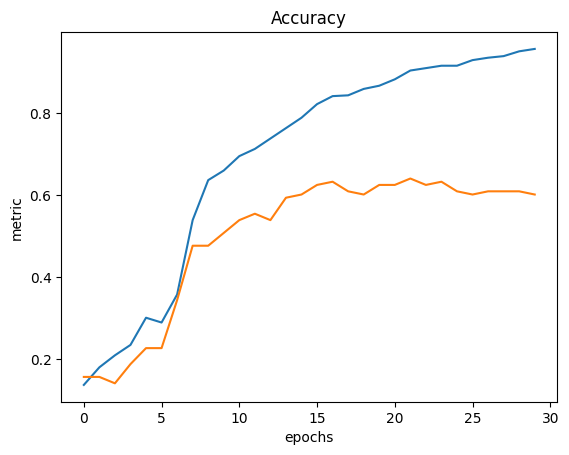

In [170]:
model = TahnResMLP()
optimizer = SGD(model.layers, lr = 1e-4)

#train params
train_start = time.time()
bs = 32
epochs = 3_0
eval_freq = 1

#train
train_start = time.time()
n_s = train_size // bs

train_losses = []
train_acuracy_scores = []
test_losses = []
test_acuracy_scores = []
train_apendix = train_size % bs
test_apendix = test_size % bs
for step in tqdm(range(epochs)):
    preds = []
    cum_loss = 0
    for i in range(n_s):
        #batch prep
        input = train_set[:, i*bs:(i+1)*bs]
        target = train_gt_set[:, i*bs:(i+1)*bs]        
        #batch processing
        optimizer.zero_grad()
        # for layer in model:
        #     out = layer(out)
        out = model(input.copy())
            
        #loss calc
        loss = cross_entropy(out, target)
        loss.backward()
        optimizer.optimize(loss.data)
        
        #loggin
        predicted = np.argmax(out.data, axis = 0)
        preds.append(predicted)
        cum_loss += loss.data

    #eval
    if step % eval_freq == 0:
        #train_eval
        ac = accuracy_score(np.stack(preds).reshape(-1,), y_a[:train_size - train_apendix])
        train_acuracy_scores.append(ac)
        train_losses.append(cum_loss/(train_size - train_apendix))

        #test_eval
        optimizer.zero_grad()
        #out = test_set.copy()
        out = model(test_set.copy())
            
        test_predicted = np.argmax(out.data, axis = 0)
        
        test_loss = cross_entropy(out, test_gt_set).data / (test_size)# - eval_apendix)
        test_losses.append(test_loss)
        ac = accuracy_score(np.stack(test_predicted).reshape(-1,), y_b[:test_size])
        test_acuracy_scores.append(ac)
        

train_end = time.time()
print("t: ", train_end - train_start)
print('CELoos on the last epoch')
print('train: ',train_losses[-1])
print('test: ',test_losses[-1])
print('Accuracy on the last epoch')
print('train: ',train_acuracy_scores[-1])
print('test: ',test_acuracy_scores[-1])
plt.plot(train_losses, label = 'train')
plt.plot(test_losses, label = 'test')
plt.title('CE loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()
plt.plot(train_acuracy_scores, label = 'train')
plt.plot(test_acuracy_scores, label = 'test')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('metric')
plt.show()

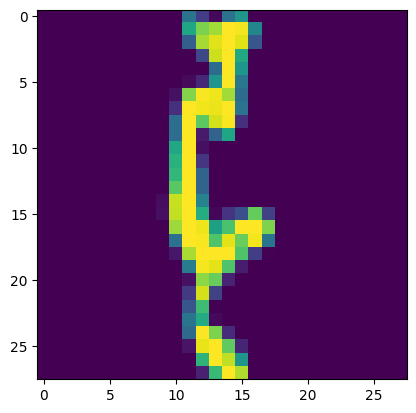

true label:  2
predicted:  [5]


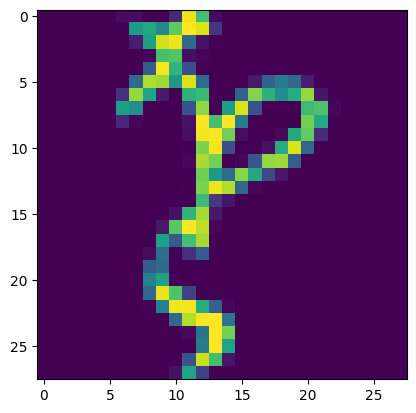

true label:  9
predicted:  [2]


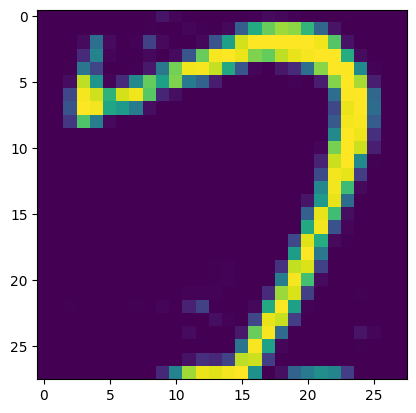

true label:  3
predicted:  [2]
mean time to predict:  0.00033791859944661457


In [171]:
stop_flag = 0
mean_time = []
for i in range(100):
    input = test_set[:, i:i+1]
    t_0 = time.time()
    predict = model(input.copy())
    t_1 = time.time()
    mean_time.append(t_1 - t_0)
    pre_label = np.argmax(predict.data, axis = 0)
    if pre_label != y_b[i]:
        plt.imshow(input.reshape(28, -1))
        plt.show()
        print('true label: ', y_b[i])
        print('predicted: ', pre_label)
        stop_flag +=1

    if stop_flag ==3:
        break
print('mean time to predict: ', np.mean(np.array(mean_time)))

LeakyRelu

100%|██████████| 30/30 [00:01<00:00, 27.66it/s]


t:  1.0884747505187988
CELoos on the last epoch
train:  0.018243934943796388
test:  0.18690110190981077
Accuracy on the last epoch
train:  0.94140625
test:  0.5703125


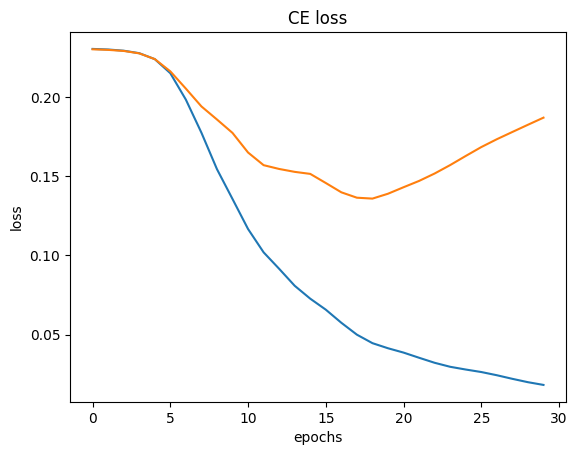

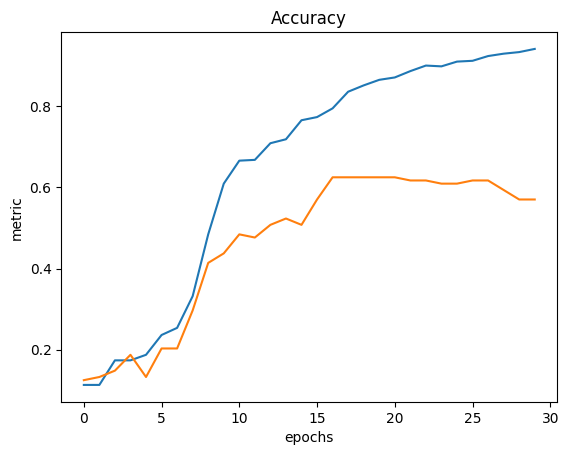

In [172]:
model = LeakyResMLP()
optimizer = SGD(model.layers, lr = 1e-4)

#train params
train_start = time.time()
bs = 32
epochs = 3_0
eval_freq = 1

#train
train_start = time.time()
n_s = train_size // bs

train_losses = []
train_acuracy_scores = []
test_losses = []
test_acuracy_scores = []
train_apendix = train_size % bs
test_apendix = test_size % bs
for step in tqdm(range(epochs)):
    preds = []
    cum_loss = 0
    for i in range(n_s):
        #batch prep
        input = train_set[:, i*bs:(i+1)*bs]
        target = train_gt_set[:, i*bs:(i+1)*bs]        
        #batch processing
        optimizer.zero_grad()
        # for layer in model:
        #     out = layer(out)
        out = model(input.copy())
            
        #loss calc
        loss = cross_entropy(out, target)
        loss.backward()
        optimizer.optimize(loss.data)
        
        #loggin
        predicted = np.argmax(out.data, axis = 0)
        preds.append(predicted)
        cum_loss += loss.data

    #eval
    if step % eval_freq == 0:
        #train_eval
        ac = accuracy_score(np.stack(preds).reshape(-1,), y_a[:train_size - train_apendix])
        train_acuracy_scores.append(ac)
        train_losses.append(cum_loss/(train_size - train_apendix))

        #test_eval
        optimizer.zero_grad()
        #out = test_set.copy()
        out = model(test_set.copy())
            
        test_predicted = np.argmax(out.data, axis = 0)
        
        test_loss = cross_entropy(out, test_gt_set).data / (test_size)# - eval_apendix)
        test_losses.append(test_loss)
        ac = accuracy_score(np.stack(test_predicted).reshape(-1,), y_b[:test_size])
        test_acuracy_scores.append(ac)
        

train_end = time.time()
print("t: ", train_end - train_start)
print('CELoos on the last epoch')
print('train: ',train_losses[-1])
print('test: ',test_losses[-1])
print('Accuracy on the last epoch')
print('train: ',train_acuracy_scores[-1])
print('test: ',test_acuracy_scores[-1])
plt.plot(train_losses, label = 'train')
plt.plot(test_losses, label = 'test')
plt.title('CE loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()
plt.plot(train_acuracy_scores, label = 'train')
plt.plot(test_acuracy_scores, label = 'test')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('metric')
plt.show()

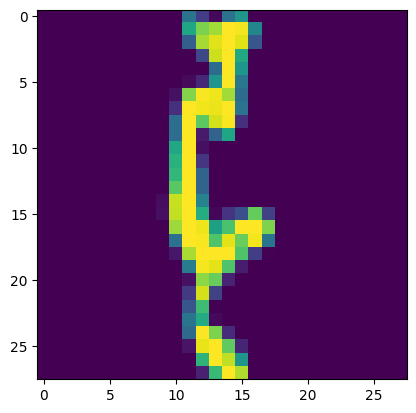

true label:  2
predicted:  [5]


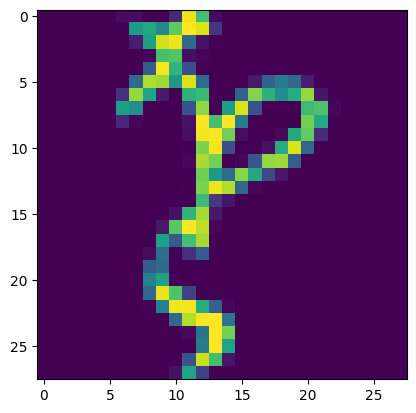

true label:  9
predicted:  [2]


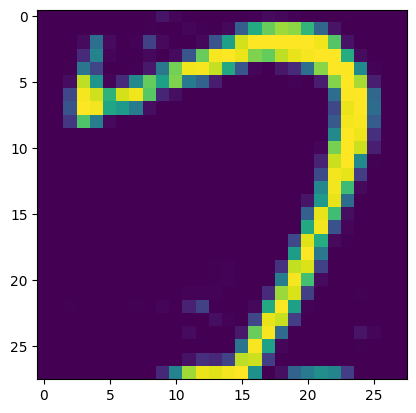

true label:  3
predicted:  [2]
mean time to predict:  0.0006126562754313151


In [173]:
stop_flag = 0
mean_time = []
for i in range(100):
    input = test_set[:, i:i+1]
    t_0 = time.time()
    predict = model(input.copy())
    t_1 = time.time()
    mean_time.append(t_1 - t_0)
    pre_label = np.argmax(predict.data, axis = 0)
    if pre_label != y_b[i]:
        plt.imshow(input.reshape(28, -1))
        plt.show()
        print('true label: ', y_b[i])
        print('predicted: ', pre_label)
        stop_flag +=1

    if stop_flag ==3:
        break
print('mean time to predict: ', np.mean(np.array(mean_time)))

Під час виконання роботи було реалізовано багатошаровий перцептрон з разними функціями активаціями. Для навчальних цілей було обрано маленьку вибірку 80/20 і навчено три моделі з однаковим оптимізатором (SGD), однаковою струтурою, яка включає в себе res-connections, тому що в противному випадку навчати модель - складніше, адже не використовуються жодні техники, для зменшення вибуху / сатурації градієнтів, окрім нормалізації вхідних даних. Була використана голова log-softmax, тому що обираємо лейбл все одно за argmax, а так ще й додаємо чисельну стабільність в CE+Softmax. Як і варто було очікувати, tanh показав себе найкраще з функцій активації, адже це єдина розглянута нелінійна функція, проте tanh додає незначне збільшення в навантаженні на обробку даних. Нормалізовувалися дані через ділення на 255 (максимальне значення пікселя). На графіках ми бачимо однакові випадки міскласифікації, адже ініціалізація моделей майже однакова, структру, датасети та порядок отримання батчей - однакові.